In [ ]:
import torch # as cp
import numpy as np

import sys 
sys.path.append("/home/oem/Documents/ML-Control-Rob/levelsetpy/")
import numpy as np
import scipy.linalg as la
import scipy.sparse as sparse
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
# from levelsetpy.utilities.matlab_utils import isColumnLength, isvector

ModuleNotFoundError: No module named 'torch'

## Problem Statement and Numerical Setting

Let $\Omega = [0,L]\subset \mathbb{R}$ be the spatial domain indicated by the variable $\omega$, and let $(0,T]\subset\mathbb{R}$ be the time domain with variable $t$.
We consider the three-dimensional HJ equation with homogeneous Dirichlet boundary conditions,
$$
\begin{align*}
    &\partial \bm{v}_t(t; \bm{x}) + \min\{0, \bm{H}\left(x, \partial \bm{v}_{\bm{x}}(t; \bm{x})\right)\} = 0, \qquad &\bm{v}(0; \bm{x}) = \bm{g}(0; \bm{x}) \nonumber \\
%\bm{v}(0; \bm{x}) &= \bm{g}(0; \bm{x}) \\
%
&\approx \partial \bm{v}^\delta_t(t; \bm{x}) + \min\{0, 
\bm{H}^\delta\left(t; x, \partial \bm{v}^\delta_{\bm{x}}\right)\} = 0, \qquad &\bm{v}^\delta(0; \bm{x}) = \bm{g}(0; \bm{x}) \nonumber \\
%
&:= \partial \bm{v}^\delta_t(t; \bm{x}) + \min\bigg\{0, 
\max_{\bm{u} \in \mathcal{U}} \min_{\bm{w} \in \mathcal{W}} \, \bigg\langle f(t; \bm{x}, \bm{u}, \bm{w}), \frac{1}{t}(\bm{x} - \text{prox}_{t\bm{g}}(\bm{x})) \bigg\rangle
\bigg\} = 0 \qquad &\bm{v}^\delta(0; \bm{x}) = \bm{g}(0; \bm{x}).
\end{align*}
$$

This is a model for a one-dimensional rod that conducts heat: the temperature at the ends of the rod are fixed at $0$ and heat is allowed to flow out of the rod through the ends.

In [34]:

T = 1                           # Temporal domain length (final simulation time).
k = T*10**3 + 1                 # Temporal grid size.
eps = sys.float_info.epsilon

t_range = torch.linspace(0, T, k)
t_steps = t_range[1] -  t_range[0]

# inputs 
u_bound = 1
w_bound = 1

u = lambda u: u*u_bound
w = lambda w: w*w_bound

# generate the spatial domain whereupon v(t;x) is domiciled
L = 100 #64                           # Spatial domain length.
resolution = 100                   # Spatial domain resolution.
# State components, $(x, z, \theta)$
state_x = torch.linspace(-L, +L, resolution)  # x spatial grid.
state_z = torch.linspace(-L, +L, resolution)  # x spatial grid.
state_orient = torch.linspace(-torch.pi/2, +torch.pi/2, resolution)  # x spatial grid.

X_all, Z_all, Theta_all = torch.meshgrid(*(state_x, state_z, state_orient), indexing='ij') #, sparse=False)

# interior of the spatial grids ==> Domain of the problem 
X_int = X_all[1:-1, 1:-1, 1:-1]
Z_int = Z_all[1:-1, 1:-1, 1:-1]
Theta_int = Theta_all[1:-1, 1:-1, 1:-1]


# initial conditions
X_0 = L/2.0 * torch.ones_like(X_int) #0*X_int
Z_0 = L/2.0 * torch.ones_like(X_int) #0*Z_int
Theta_0 = -torch.pi/4.0  # [-pi/2. pi/2]

In [3]:
class RocketDynamics():
    def __init__(self, u_bound=1, w_bound=1, T=1, L=64, a=32, g=32, resolution=100):    
        """
            Rockets Dynamics in relative coordinates.
            The equations of motion are adopted from Dreyfus' construction.

            In relative coordinates between the two rockets, we have
                    &\dot{x} = a(cos(u_p)+ cos(u_e)),\\
                    &\dot{z} = a(sin(u_p)+sin(u_e))-2g,\\
                    &\dot{\theta} = u_p - u_e

            Parameters
            ==========
                u_bound: absolute value of the linear speed of the vehicle.
                w_bound: absolute value of the angular speed of the vehicle.
                T:  Temporal domain length (final simulation time).
                L: Spatial domain resolution.
                a: acceleration in ft/sec^2.
                g: gravitational acceleration in ft/sec^2.
                resolution: spattial domain resolution.
        
        """    
        self.T = T                      # Temporal domain length (final simulation time).
        k = T*10**3 + 1                 # Temporal grid size.
        self.eps = sys.float_info.epsilon

        self.t_range = torch.linspace(0, T, k)
        t_steps = t_range[1] -  t_range[0]

        # inputs 
        u = lambda u: u*u_bound
        w = lambda w: w*w_bound

        self.resolution = resolution                   # Spatial domain resolution.

        # generate the spatial domain whereupon v(t;x) is domiciled
        self.state_space = self.get_state_space()
        self.state_domain = self.get_state_domain()
        self.initial_conditions = self.get_initial_conditions()
        self.value_function = self.get_value_function(a, g)

    def get_state_space(self, L, resolution):        
        # State components, $(x, z, \theta)$
        state_x = torch.linspace(-L, +L, resolution)  # x spatial grid.
        state_z = torch.linspace(-L, +L, resolution)  # x spatial grid.
        state_orient = torch.linspace(-torch.pi/2, +torch.pi/2, resolution)  # x spatial grid.
        X_all, Z_all, Theta_all = torch.meshgrid(*(state_x, state_z, state_orient), indexing='ij') 
        
        return X_all, Z_all, Theta_all
    
    def get_state_domain(self):
        # interior of the spatial grids ==> Domain of the problem 
        X, Z, Theta = self.state_space

        X_int = X[1:-1, 1:-1, 1:-1]
        Z_int = Z[1:-1, 1:-1, 1:-1]
        Theta_int = Theta[1:-1, 1:-1, 1:-1]

        return X_int, Z_int, Theta_int

    def get_initial_conditions(self):
        X_int, Z_int, Theta_int = self.state_domain
        # initial conditions
        X_0 = L/2.0 * torch.ones_like(X_int) 
        Z_0 = L/2.0 * torch.ones_like(Z_int) 
        Theta_0 = -torch.pi/4.0 * torch.ones_like(Z_int)

        return X_0, Z_0, Theta_0
    
    def get_value_functions(self, a, g):
        """
            The value is the l\_2 distance to the boundary of the target region in the x-z plane.
        """

        ap = a; ae = a 

        X, _, Theta = self.state_space

        values = torch.sqrt(ap * torch.cos(Theta)**2  + (ae * torch.sin(Theta) + ap + u * X - g)**2)

        return values 

In [4]:
rock_dyn = RocketDynamics(1, 1, T=1, L=100, a=1, g=32, resolution=100)

NameError: name 'sys' is not defined

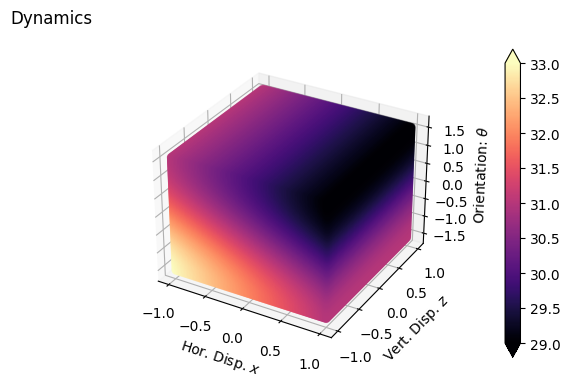

In [ ]:
# plot solution space in space time 
fig = plt.figure(figsize=(16,4), )
ax = fig.add_subplot(111, projection='3d')

# Plot a few snapshots.
color = iter(plt.cm.viridis(np.linspace(.25, 1, 5)))

ap = 32; u = 1; g = 32; ae = ap;

# values = signed distance to target
values = torch.sqrt(ap * torch.cos(Theta_all) * (ap * torch.cos(Theta_all)) + (ae * torch.sin(Theta_all) + ap + u * X_all - g)**2)
cdata = ax.scatter(X_all, Z_all, Theta_all, c=values, cmap="magma") #, shading="nearest", 
plt.colorbar(cdata, ax=ax, extend="both")
ax.set_xlabel(r"Hor. Disp. $x$")
ax.set_ylabel(r"Vert. Disp. $z$")
ax.set_zlabel(r"Orientation: $\theta$")

fig.suptitle("Dynamics")
plt.show()

In [ ]:

def compute_prox(x, t, f, delta=1e-1, int_samples=100, alpha=1.0, linesearch_iters=0, device='cpu'):
    """ Estimate proximals from function value sampling via HJ-Prox Algorithm.

        The output estimates the proximal:
        
        $$
            \mathsf{prox_{tf}(x) = argmin_y \ f(y) + \dfrac{1}{2t} \| y - x \|^2,}
        $$
            
        where $\mathsf{x}$ = `x` is the input, $\mathsf{t}$=`t` is the time parameter, 
        and $\mathsf{f}$=`f` is the function of interest. The process for this is 
        as follows.
        
        - [x] Sample points $\mathsf{y^i}$ (via a Gaussian) about the input $\mathsf{x}$
        - [x] Evaluate function $\mathsf{f}$ at each point $\mathsf{y^i}$
        - [x] Estimate proximal by using softmax to combine the values for $\mathsf{f(y^i)}$ and $\mathsf{y^i}$            

        Note: 
            The computation for the proximal involves the exponential of a potentially
            large negative number, which can result in underflow in floating point
            arithmetic that renders a grossly inaccurate proximal calculation. To avoid
            this, the "large negative number" is reduced in size by using a smaller
            value of alpha, returning a result once the underflow is not considered
            significant (as defined by the tolerances "tol" and "tol_underflow").
            Utilizing a scaling trick with proximals, this is mitigated by using
            recursive function calls.
            
        Warning:
            Memory errors can occur if too many layers of recursion are used,
            which can happen with tiny delta and large f(x). 

        Args:
            x (tensor): Input vector
            t (tensor): Time > 0
            f (Callable): Function to minimize
            delta (float, optional): Smoothing parameter
            int_samples (int, optional): Number of samples in Monte Carlo sampling for integral
            alpha (float, optional): Scaling parameter for sampling variance
            linesearch_iters (int, optional): Number of steps used in recursion (used for numerical stability)
            device (string, optional): Device on which to store variables

        Shape:
            - Input `x` is of size `(n, 1)` where `n` is the dimension of the space of interest
            - The output `prox_term` also has size `(n, 1)`

        Returns:
            prox_term (tensor): Estimate of the proximal of f at x
            linesearch_iters (int): Number of steps used in recursion (used for numerical stability)
            envelope (tensor): Value of envelope function (i.e. infimal convolution) at proximal
            
        Example:
            Below is an exmaple for estimating the proximal of the L1 norm. Note the function
            must have inputs of size `(n_samples, n)`.
            ```
                def f(x):
                    return torch.norm(x, dim=1, p=1) 
                n = 3
                x = torch.randn(n, 1)
                t = 0.1
                prox_term, _, _ = compute_prox(x, t, f, delta=1e-1, int_samples=100)   
            ```
    """
    assert x.shape[1] == 1
    assert x.shape[0] >= 1
    
    linesearch_iters +=1
    standard_dev = np.sqrt(delta * t / alpha)
    dim = x.shape[0]
    
    y = standard_dev * torch.randn(int_samples, dim, device=device) + x.permute(1,0) # y has shape (n_samples, dim)
    z = -f(y)*(alpha/delta)     # shape =  n_samples
    w = torch.softmax(z, dim=0) # shape = n_samples 
    
    softmax_overflow = 1.0 - (w < np.inf).prod()
    if softmax_overflow:
        alpha *= 0.5
        return compute_prox(x, t, f, delta=delta, int_samples=int_samples, alpha=alpha,
                            linesearch_iters=linesearch_iters, device=device)
    else:
        prox_term = torch.matmul(w.t(), y)
        prox_term = prox_term.view(-1,1)
    
    prox_overflow = 1.0 - (prox_term < np.inf).prod()
    assert not prox_overflow, "Prox Overflowed"

    envelope = f(prox_term.view(1,-1)) + (1/(2*t)) * torch.norm(prox_term - x.permute(1,0), p=2)**2    
    return prox_term, linesearch_iters, envelope

In [ ]:
# set up value function integration
t_now = t_range[0] 
small = 100* eps 
while t_range[1] - t_now > small * t_range[1]:
    # How far to step?
    t_span = np.hstack([ t_now, min(t_range[1], t_now + t_steps) ])

    grad_vx = 

In [35]:
eps 

2.220446049250313e-16